# Tutorial

This tutorial demonstrates how to use LineageVI for RNA velocity analysis with gene programs.

We will show how to:

1) Download the gene set
2) Annotate an AnnData with the gene set
3) Process the data
4) Initialize and train the model
5) Fetch the model outputs
6) Plot the phase planes
7) Visualize the velocity UMAP
8) Rank genes or gene programs across clusters
9) Run statistical tests 
10) Run perturbation experiments
11) Estimate velocity uncertainty 

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Library loading
import lineagevi
import scanpy as sc
import scvelo as scv
import numpy as np
import os

In [4]:
# Download pancreas dataset
adata = scv.datasets.pancreas()

In [5]:
# Obtain raw counts for the annotation step
adata.X = adata.layers['unspliced'].copy() + adata.layers['spliced'].copy()
adata.layers['counts'] = adata.X.copy()

In [6]:
# Explore available libraries
libs = lineagevi.utils.list_enrichr_libraries()
print(libs[["libraryName", "numTerms"]].head())

                        libraryName  numTerms
0               Genome_Browser_PWMs       615
1          TRANSFAC_and_JASPAR_PWMs       326
2         Transcription_Factor_PPIs       290
3                         ChEA_2013       353
4  Drug_Perturbations_from_GEO_2014       701


In [7]:
# Download several into a directory
lineagevi.utils.download_enrichr_libraries(
    ["GO_Biological_Process_2025", "GO_Molecular_Function_2025"],
    output_dir="/home/lgolinelli/git/lineageVI/gene_sets",
)

['/home/lgolinelli/git/lineageVI/gene_sets/GO_Biological_Process_2025.gmt',
 '/home/lgolinelli/git/lineageVI/gene_sets/GO_Molecular_Function_2025.gmt']

In [8]:
# Create the binary matrix of gene sets, filtering out any gene program with less than 12 genes for interpretability.
bio_process_path = '/home/lgolinelli/git/lineageVI/gene_sets/GO_Biological_Process_2025.gmt'
min_genes=20
lineagevi.utils.add_annotations(
    adata, 
    files=[bio_process_path],
    min_genes=min_genes,
    varm_key='I',
    uns_key='terms',
    clean=False,
    genes_use_upper=True)

# Remove genes not present in any retained terms.
adata._inplace_subset_var(adata.varm['I'].sum(1) > 0)

In [9]:
# Standard scVelo preprocessing
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000, subset_highly_variable=True, log=True)
scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
sc.tl.leiden(adata) # Using clusters helps the model to learn multi-lineage dynamics.

Filtered out 6561 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.
Logarithmized X.


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2161671/2212733455.py:3: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/

computing neighbors
    finished (0:00:12) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:02) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [10]:
# We remove terms that contain less than 12 genes after filtering out HVGs.
select_terms = adata.varm['I'].sum(0)>min_genes
adata.uns['terms'] = np.array(adata.uns['terms'])[select_terms].tolist()
adata.varm['I'] = adata.varm['I'][:, select_terms]

# Again, we remove genes not present in any retained terms.
adata._inplace_subset_var(adata.varm['I'].sum(1)>0) 

In [ ]:
# We check the final number of genes and gene programs
adata.varm['I'].shape

In [11]:
# We store the matrix of neighbors indices in the AnnData object; required for training. 
lineagevi.utils.get_neighbor_indices(adata, K=20, neighbors_key='neighbors', indices_key='indices')  # Gets 20 neighbors + self = 21 total

Train/val split: 3326 train, 370 val (train_size=0.9)
[Regime1] Epoch 1/1 - train loss: 21.4043 (recon: 13.3333, kl: 16.1419) - val loss: 13.7796 (recon: 13.1919, kl: 1.1754)
Generated monitoring plots for regime 2, epoch 0 → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/training_plots
[Regime2] Epoch 1/1 - train loss: 0.3891 (gene: 0.3891, gp: 0.9087) - val loss: 0.3499 (gene: 0.3499, gp: 0.9164)
Generated monitoring plots for regime 2, epoch 1 → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/training_plots


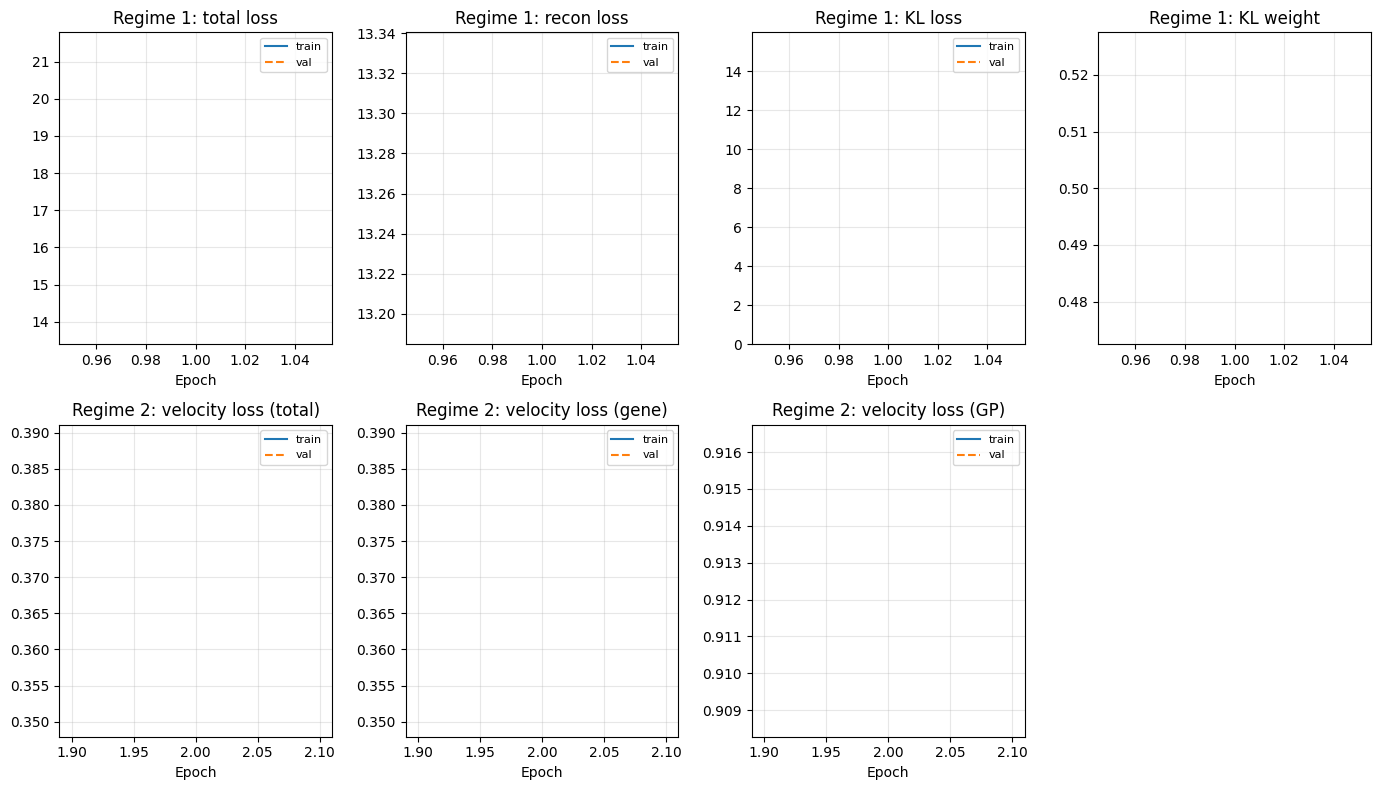

Saved loss curves → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/training_plots/loss_curves.png
Saved model  → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/pretrained_vae.pt
Saved config → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/model_config.json
Note: Call model.get_model_outputs() to annotate adata with velocities


In [ ]:
# Model initialization
vae = lineagevi.LineageVI(
    adata=adata,
    n_hidden=128,
    n_layers = 2,
    dropout = 0,
    mask_key='I',
    unspliced_key='Mu', # make sure to use smoothed spliced and unspliced expression values: 'Mu' and 'Ms'
    spliced_key='Ms',
    nn_key='indices',
    cluster_key=None,  # Key in adata.obs
    cluster_embedding_dim=12,  # Optional, default is 32
)

# Model fitting
history = vae.fit(
    K=10,
    batch_size=256,
    lr_regime1=1e-2,
    lr_regime2=1e-2,
    train_size=0.9,
    velocity_loss_weight_gene = 1.0,
    velocity_loss_weight_gp = 0,
    epochs1=1, #initially 400
    epochs2=1, #initially 100
    seeds=(0, 1, 2),
    output_dir='/home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas',   # or None
    verbose=1,
    monitor_genes=['Gnas', 'Rbfox3'],
    monitor_negative_velo=True,
    monitor_every_epochs=25,
    #kl_weight = 0.1,
    kl_weight_schedule='linear',
    kl_weight_min=0.0,
    kl_weight_max=.5,
    kl_cycle_ramp_frac=0.2,
)

In [ ]:
# Store model outputs in the anndata
vae.get_model_outputs(
    adata=adata,
    return_negative_velo=False,
    base_seed=0,
    save_to_adata=True,
    unspliced_key='Mu',
    spliced_key='Ms',
    nn_key='indices',
    rescale_velocity_magnitude=False, # the more turbulent the velocity flow, the smaller the velocity magnitude
    max_velocity_magnitude=1,
)

In [50]:
adata

AnnData object with n_obs × n_vars = 3696 × 2765
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'numerical_idx_linvi'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'terms', 'log1p', 'leiden', 'indices', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'differential_latent', 'diff_gp_velo'
    obsm: 'X_pca', 'X_umap', 'z', 'velocity_gp', 'mean', 'logvar', 'velocity_umap', 'velocity_gp_pert', 'velocity_gp_before', 'mean_pert', 'logvar_pert'
    varm: 'I', 'PCs'
    layers: 'spliced', 'unspliced', 'counts', 'Ms', 'Mu', 'recon', 'velocity_u', 'velocity', 'alpha', 'beta', 'gamma', 'velocity_u_pert', 'velocity_u_before', 'velocity_pert', '

# Gene level analysis

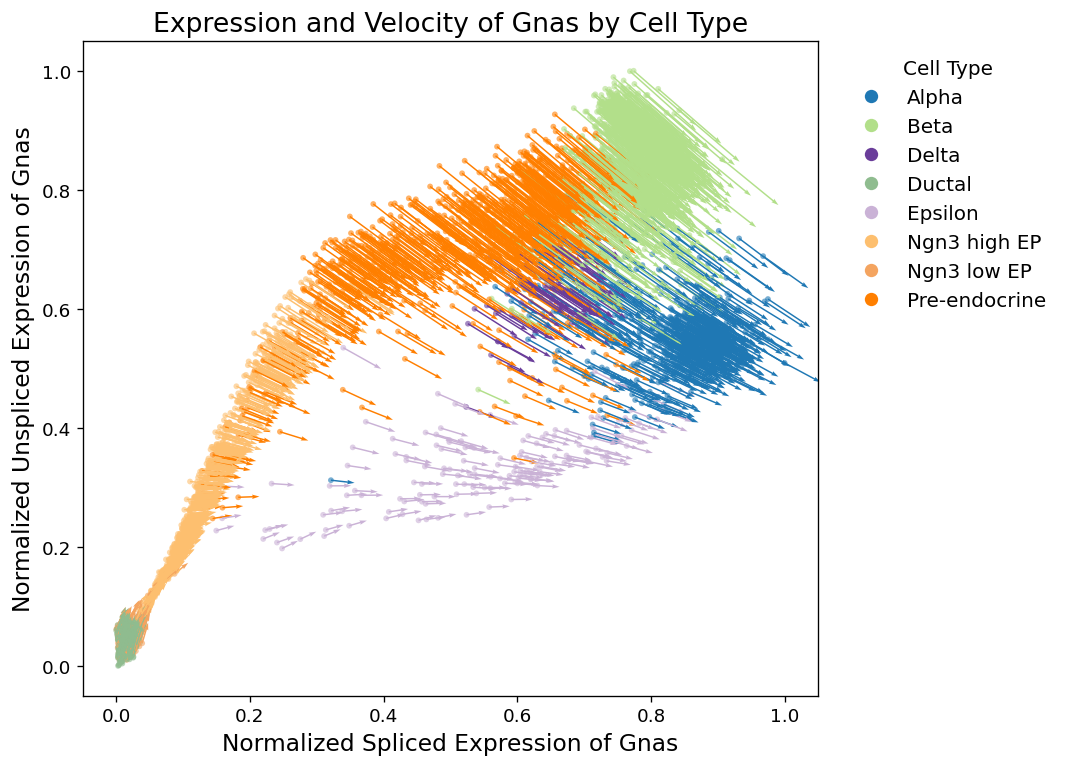

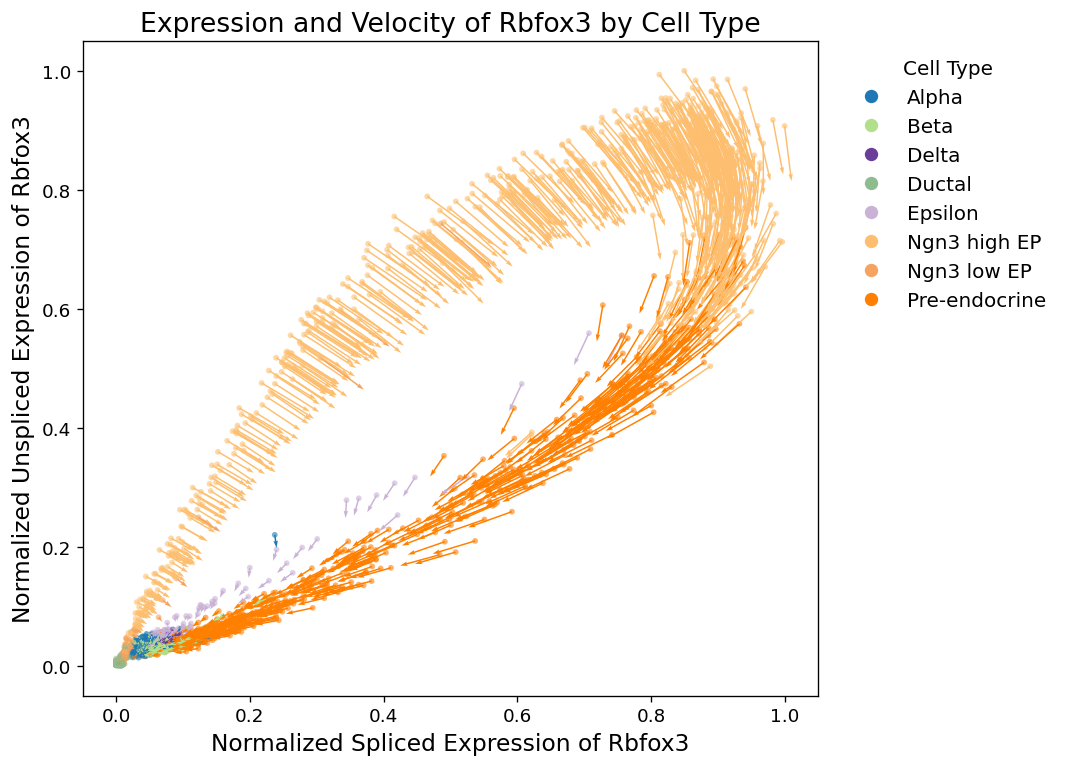

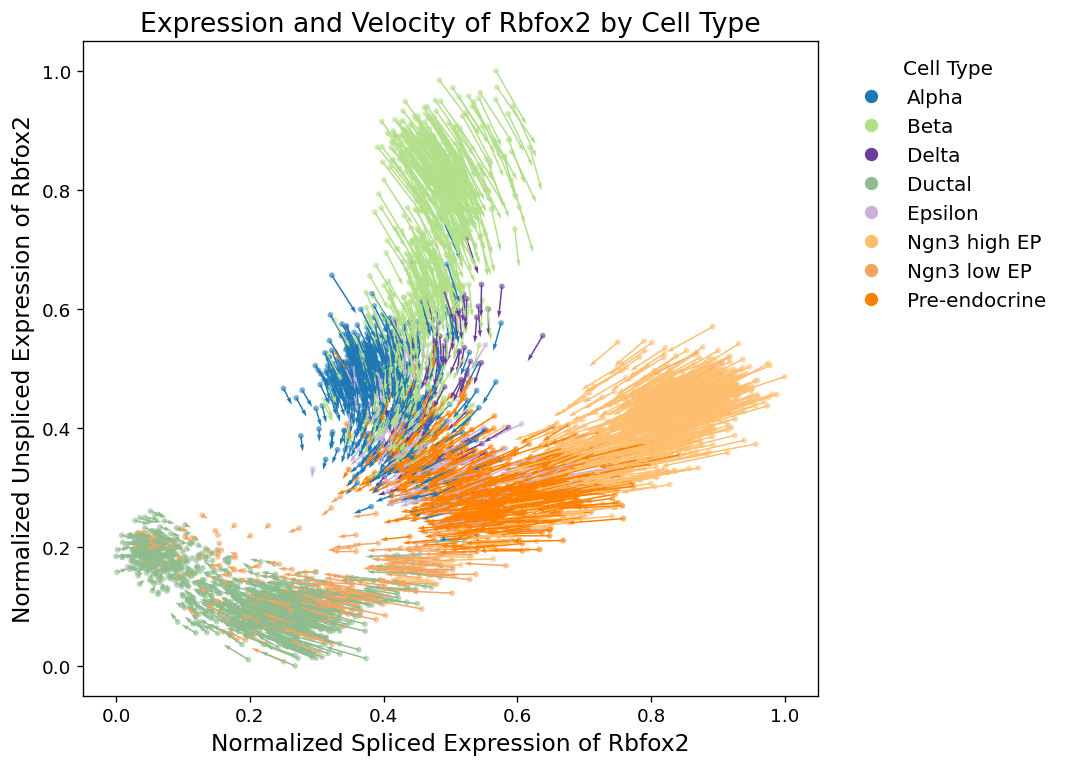

(<Figure size 1080x780 with 1 Axes>,
 <Axes: title={'center': 'Expression and Velocity of Rbfox2 by Cell Type'}, xlabel='Normalized Spliced Expression of Rbfox2', ylabel='Normalized Unspliced Expression of Rbfox2'>)

In [51]:
# Visualization of phase planes at the gene level
lineagevi.plots.plot_phase_plane(adata,  'Gnas', cluster_key='clusters', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox3', cluster_key='clusters', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox2', cluster_key='clusters', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)

In [ ]:
sc.pl.violin(adata, keys='Gcg', layer='velocity', groupby='clusters')

computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

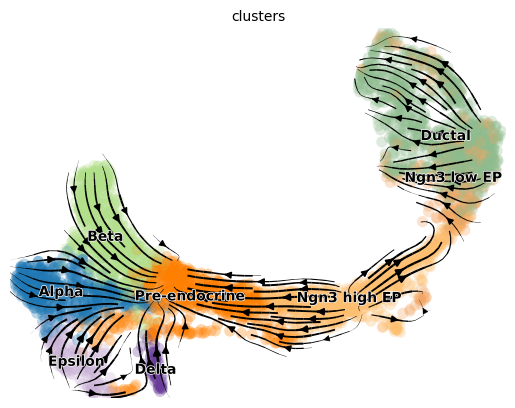

computing terminal states
    identified 4 regions of root cells and 2 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

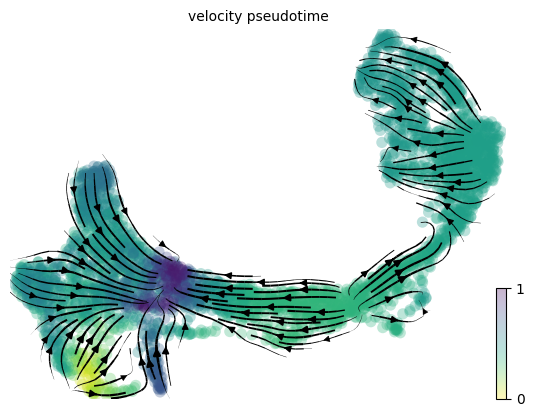

In [ ]:
# We compute the velocity UMAP
cluster_key='clusters'
sc.pp.neighbors(adata)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata)
scv.pl.velocity_embedding_stream(adata, color=cluster_key)
scv.tl.velocity_pseudotime(adata)
scv.pl.velocity_embedding_stream(adata, color='velocity_pseudotime')

In [55]:
# We rank the genes by their velocity in Beta cells
lineagevi.plots.top_features_table(adata, groupby_key="clusters", categories=['Beta', 'Ductal'], layer="velocity", n=10)

,feature,mean_activation,Beta mean,Ductal mean
1,Iapp,-306.679169,-780.092590,-1.234377
2,Nnat,-76.012665,-192.131943,-1.092943
3,Rbp4,-55.223953,-137.434006,-2.182285
4,Rpl32,-25.394569,-14.023933,-32.730854
5,Rpl18a,-25.306635,-13.952965,-32.631962
6,Rps5,-21.699022,-12.670027,-27.524511
7,Rps19,-19.749914,-10.458349,-25.744799
8,Tmsb4x,-18.772305,-17.933815,-19.313272
9,Rps9,-18.350815,-11.945456,-22.483547
10,Sst,-17.834366,-45.089237,-0.249634


computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


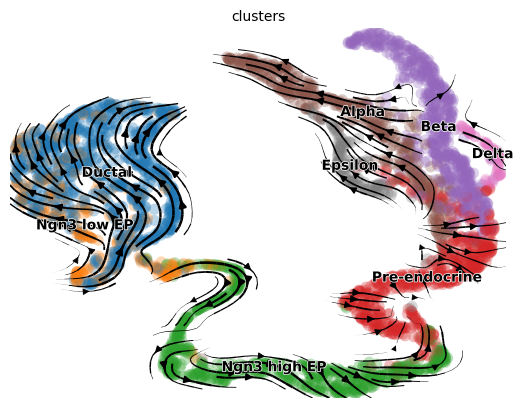

/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


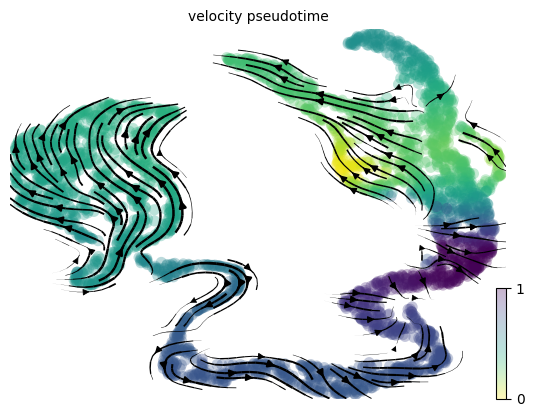

In [ ]:
# We build the gene program anndata and compute the gene program velocity UMAP in the latent space
adata_gp = lineagevi.utils.build_gp_adata(adata)
sc.pp.neighbors(adata_gp)
sc.tl.umap(adata_gp)
scv.tl.velocity_graph(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color=cluster_key)
scv.tl.velocity_pseudotime(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color='velocity_pseudotime')

In [58]:
# We rank the gene programs by their GP velocity in Beta cells
lineagevi.plots.top_features_table(adata_gp, groupby_key="clusters", categories=['Alpha'], layer="velocity", n=10)

,feature,mean_activation,Alpha mean
1,Regulation of Apoptotic Process (GO:0042981),-78.954216,-78.954216
2,Adenylate Cyclase-Modulating G Protein-Coupled...,73.211960,73.211960
3,Glucose Homeostasis (GO:0042593),-70.866158,-70.866158
4,Cellular Response to Peptide Hormone Stimulus ...,-46.761566,-46.761566
5,Regulation of Protein Secretion (GO:0050708),-39.708935,-39.708935
6,Negative Regulation of Apoptotic Process (GO:0...,-38.493328,-38.493328
7,Regulation of Insulin Secretion (GO:0050796),-35.270901,-35.270901
8,Protein Metabolic Process (GO:0019538),34.317417,34.317417
9,Regulation of ERK1 and ERK2 Cascade (GO:0070372),32.801777,32.801777
10,Positive Regulation of Gene Expression (GO:001...,28.260571,28.260571


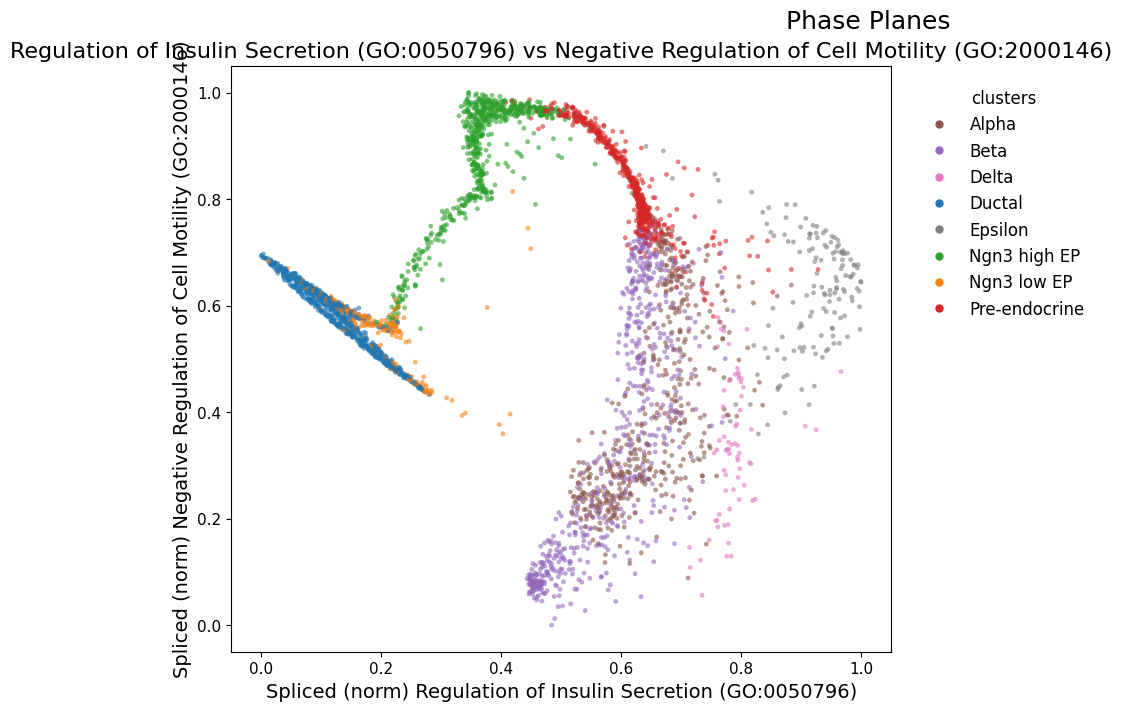

(<Figure size 1400x700 with 2 Axes>,
 array([[<Axes: title={'center': 'Regulation of Insulin Secretion (GO:0050796) vs Negative Regulation of Cell Motility (GO:2000146)'}, xlabel='Spliced (norm) Regulation of Insulin Secretion (GO:0050796)', ylabel='Spliced (norm) Negative Regulation of Cell Motility (GO:2000146)'>,
         <Axes: >]], dtype=object))

In [59]:
# We plot pairs of gene programs, showing the gene program velocity in the space of latent state
lineagevi.plots.plot_gp_phase_planes(
    adata_gp,
    program_pairs=[('Regulation of Insulin Secretion (GO:0050796)', 'Negative Regulation of Cell Motility (GO:2000146)')],
    cluster_key='clusters',
    title='Phase Planes',
    figsize_per_panel = (7, 7),
    alpha = 1,
    arrow_multiplier=.01
)

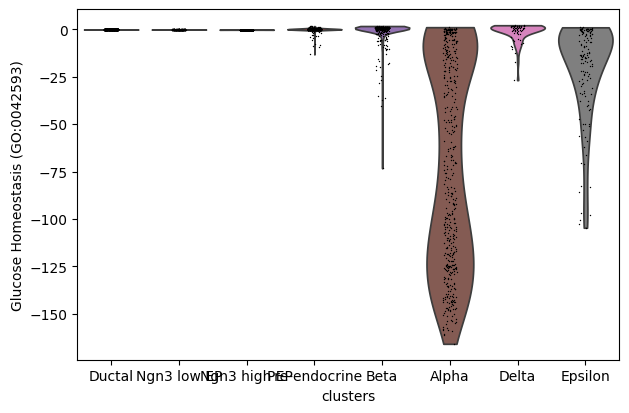

In [ ]:
# We plot the velocity of a gene program in the space of latent state
sc.pl.violin(adata_gp, keys='Glucose Homeostasis (GO:0042593)', layer='velocity', groupby='clusters')

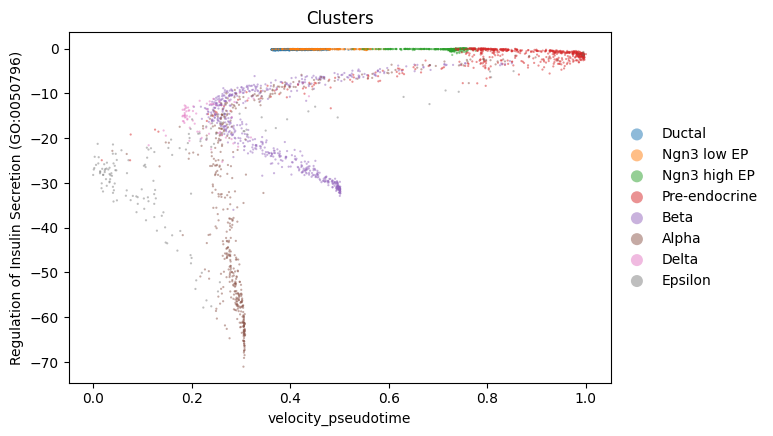

In [35]:
sc.pl.scatter(adata_gp, x='velocity_pseudotime', y='Regulation of Insulin Secretion (GO:0050796)', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

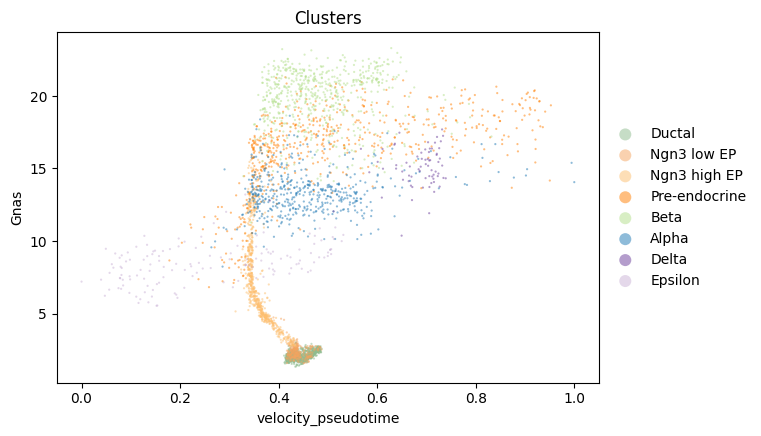

In [36]:
sc.pl.scatter(adata, x='velocity_pseudotime', y='Gnas', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

In [26]:
#sc.pl.scatter(adata, x='velocity_pseudotime', y='Gnas', color='clusters', layers='Ms', size=10, alpha=0.5, title='Clusters')

In [37]:
# Differential expression (e.g. spliced layer)
#de = vae.differential(adata, "clusters", mode="expression", layer="Ms")
# de["Beta"] has columns: difference, pval, padj; index = gene names

# Differential latent (gene program activations)
dlatent = vae.differential(adata, "clusters", mode="latent")
adata.uns['differential_latent'] = dlatent

# Differential gene velocity
#dvelo = vae.differential(adata, "clusters", mode="gene_velocity")

# Differential GP velocity
dgp = vae.differential(adata, "clusters", mode="gp_velocity")
adata.uns['diff_gp_velo'] = dgp


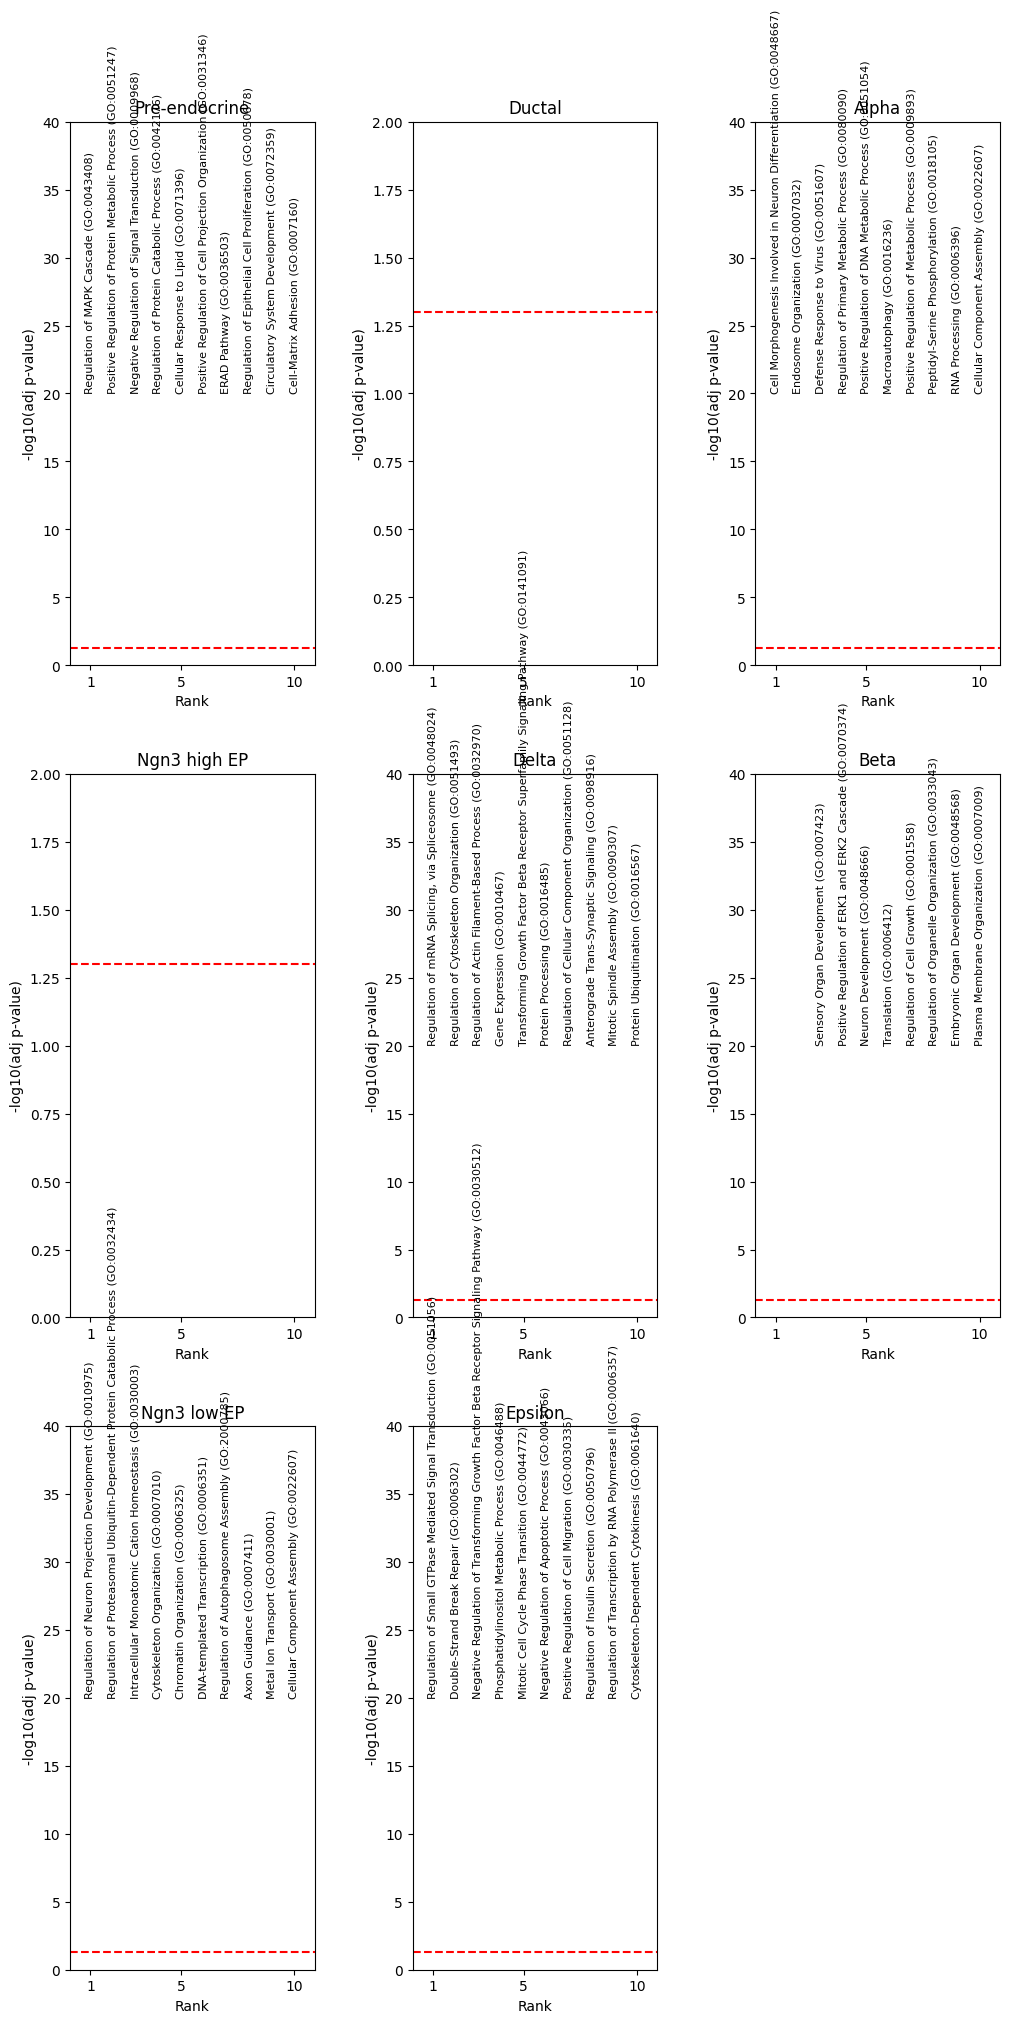

In [28]:
lineagevi.plots.plot_differential(adata, scores_key='differential_latent', n_points=10, lim_val=1.3)

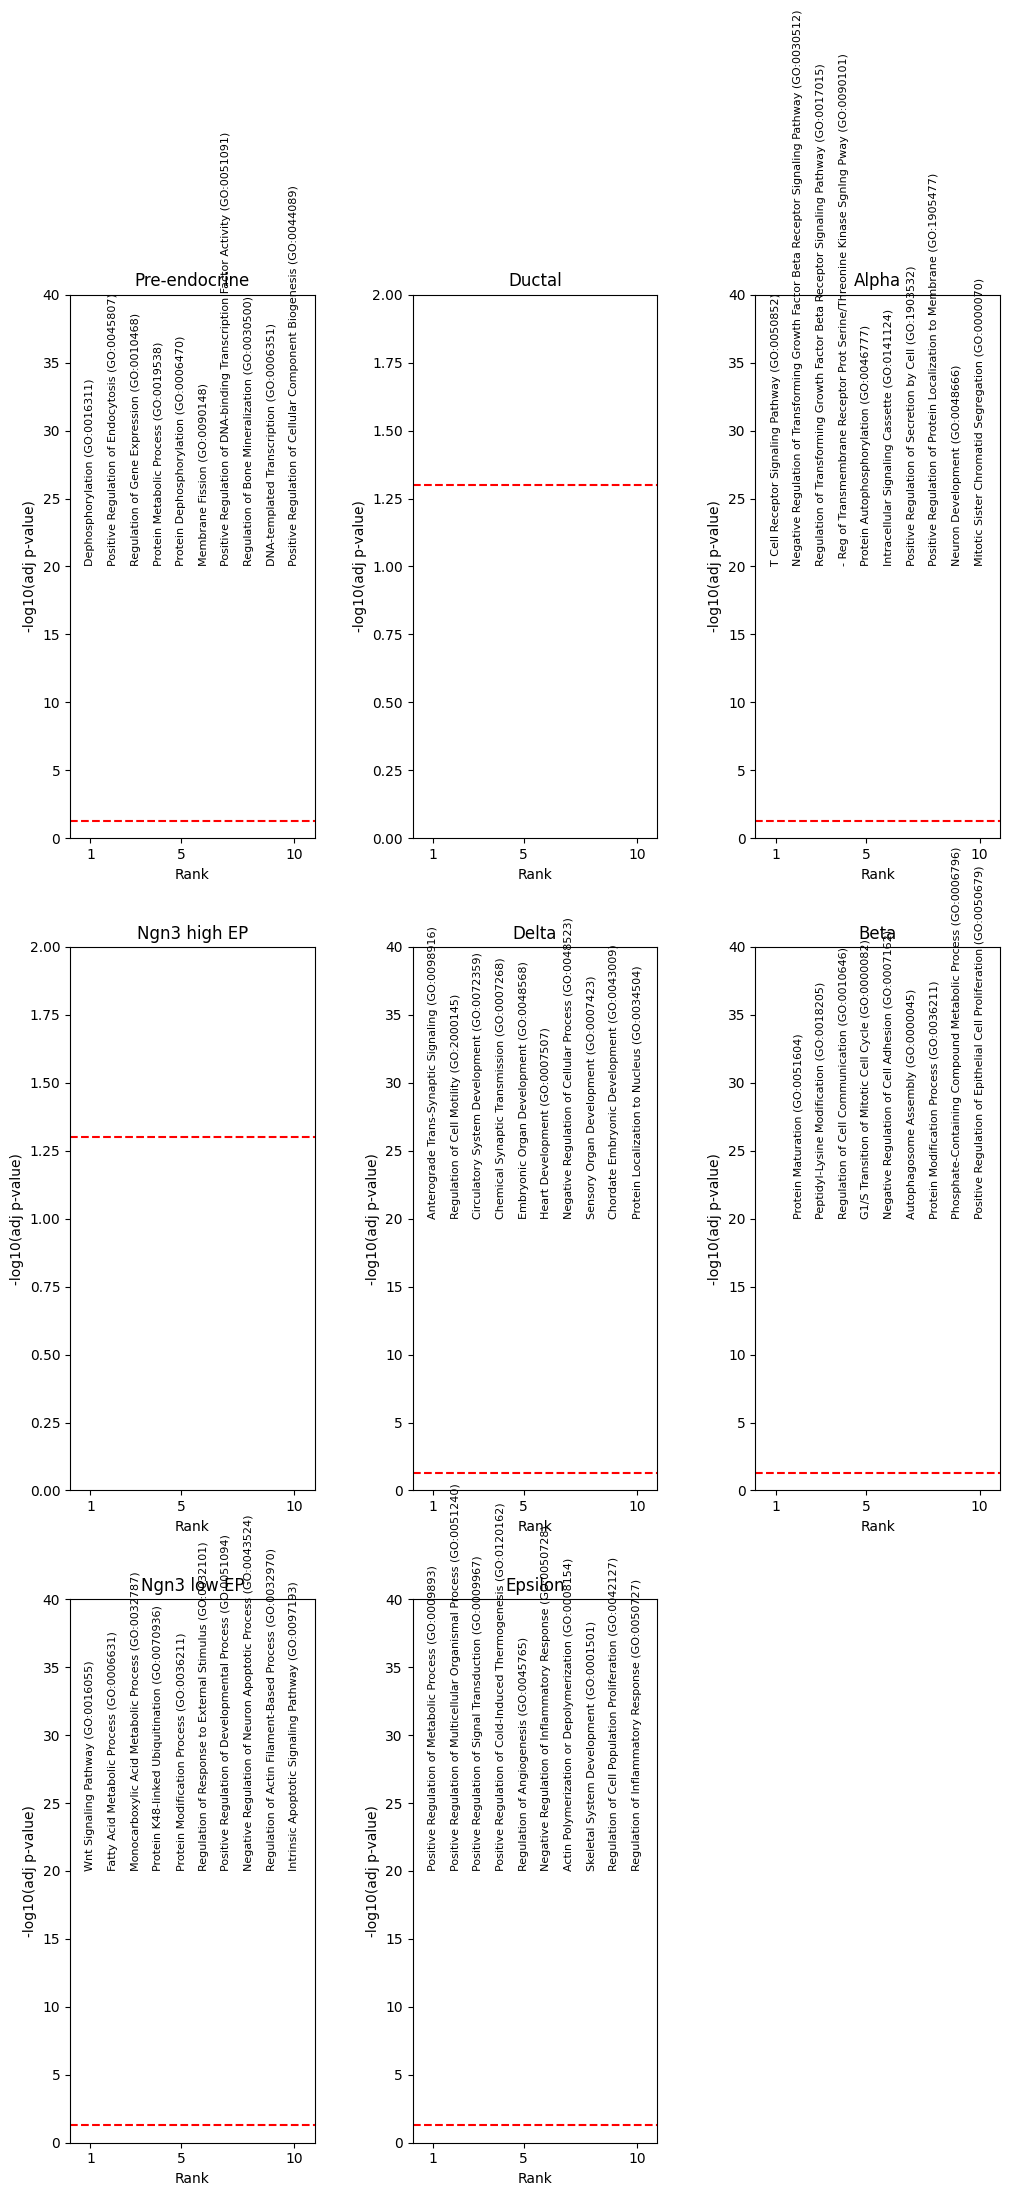

In [38]:
lineagevi.plots.plot_differential(adata, scores_key='diff_gp_velo', n_points=10, lim_val=1.3)

/mnt/beegfs/home/lgolinelli/git/lineageVI/src/lineagevi/plots.py:1125: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(adata.obs[col]):


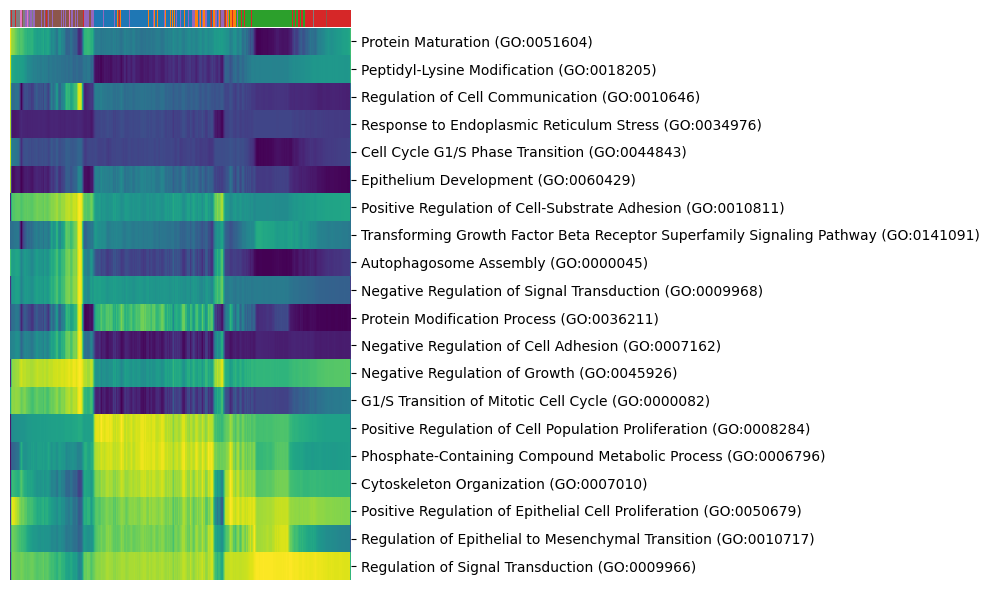

In [40]:
diff = adata.uns['diff_gp_velo']   # or 'differential_latent' for GPs
group = 'Beta'
top_n = 20
gene_list = diff[group].index[:top_n].tolist()   # already sorted by padj

lineagevi.plots.heatmap(
    adata_gp,
    gene_list,
    sortby='velocity_pseudotime',
    layer='Ms',
    col_color='clusters',
    figsize=(10, 6),
)

In [41]:
# Example 2: Perturb genes (knockdown to zero in Beta cells)
df_genes, df_gps, perturbed_outputs = vae.perturb(
    adata,
    mode='genes',
    groupby_key='clusters',
    group_to_perturb='Beta',
    genes_to_perturb=['Sntg1', 'Snhg6'],
    perturb_value=0,
    perturb_spliced=True,
    perturb_unspliced=True,
)



Perturbed outputs stored in adata:
  adata.obsm['velocity_gp_before'] / ['velocity_gp_pert']: GP velocity before/after (shape: (3696, 420))
  adata.layers['velocity_before'] / ['velocity_pert']: Gene velocity (spliced) before/after (shape: (3696, 2765))
  adata.layers['velocity_u_before'] / ['velocity_u_pert']: Gene velocity (unspliced) before/after (shape: (3696, 2765))
  adata.obsm['mean_pert']: Perturbed latent means (shape: (3696, 420))
  adata.obsm['logvar_pert']: Perturbed latent logvars (shape: (3696, 420))
  adata.layers['velocity_u_pert']: Unspliced velocities (shape: (3696, 2765))
  adata.layers['velocity_pert']: Spliced velocities (shape: (3696, 2765))
  adata.layers['alpha_pert']: Transcription rates (shape: (3696, 2765))
  adata.layers['beta_pert']: Splicing rates (shape: (3696, 2765))
  adata.layers['gamma_pert']: Degradation rates (shape: (3696, 2765))
  adata.layers['recon_pert']: Reconstructions (shape: (3696, 2765))
  (Stored for 591 perturbed cell(s))



In [43]:
perturbed_outputs

{'recon': array([[ 0.10291622,  0.01508296,  0.15853868, ...,  0.14477727,
          0.17251113,  0.15619361],
        [ 0.0953313 ,  0.06155385,  0.16701853, ...,  0.14687291,
          0.18613161,  0.16356216],
        [ 0.05715379,  0.13046804,  0.15444164, ...,  0.12723103,
          0.11763041,  0.17859927],
        ...,
        [ 0.11328698,  0.07520086,  0.16604932, ...,  0.14072067,
          0.1840181 ,  0.18286756],
        [ 0.11066993,  0.09919889,  0.16405359, ...,  0.16471091,
          0.17676404,  0.17332491],
        [ 0.06104384, -0.02490427,  0.17232908, ...,  0.1132458 ,
          0.14548002,  0.15047213]], shape=(591, 2765), dtype=float32),
 'mean': array([[-0.03867464,  0.09677657, -0.07254084, ...,  0.0134957 ,
          0.08214198, -0.00055502],
        [-0.04727674,  0.08576141, -0.06862921, ...,  0.02383525,
          0.07528578,  0.00589231],
        [-0.04167552,  0.09212181, -0.07116535, ...,  0.01688677,
          0.0807403 ,  0.00122004],
        ...,
   

In [45]:
df_genes

,genes,unspliced_velocity_before,unspliced_velocity_after,unspliced_velocity_diff,velocity_before,velocity_after,velocity_diff,pval_unspliced_velocity,padj_unspliced_velocity,pval_velocity,padj_velocity
0,Tcea1,-0.106933,-0.106424,0.000509,0.003776,0.001522,-0.002254,0.132075,0.582199,0.000126,0.202123
1,Tmem258,-0.312226,-0.311409,0.000816,0.270151,0.268823,-0.001328,0.004015,0.236208,0.000146,0.202123
2,Rgma,0.014889,0.015001,0.000112,-0.000346,-0.000306,0.000040,0.042545,0.432538,0.001585,0.209801
3,Slc25a13,0.006797,0.006586,-0.000211,-0.004998,-0.005357,-0.000359,0.096077,0.534364,0.001347,0.209801
4,Lrch1,-0.125235,-0.121583,0.003652,-0.123747,-0.126338,-0.002592,0.001968,0.192743,0.001632,0.209801
...,...,...,...,...,...,...,...,...,...,...,...
2760,Golga2,-0.089245,-0.089190,0.000055,0.017982,0.017943,-0.000040,0.737659,0.912851,0.999424,1.000000
2761,Kif22,0.011598,0.011692,0.000094,0.071870,0.071905,0.000035,0.903403,0.967807,0.999231,1.000000
2762,Vamp5,0.008771,0.008796,0.000026,0.000965,0.000967,0.000002,0.775561,0.920003,0.997935,1.000000
2763,Dnmt3a,-0.111132,-0.109764,0.001368,-0.247265,-0.246834,0.000431,0.518858,0.824034,0.997694,1.000000


In [44]:
df_gps

,terms,gp_velocity_before,gp_velocity_after,gp_velocity_diff,pval_gp_velocity,padj_gp_velocity
0,Glucose Homeostasis (GO:0042593),-0.563738,-0.547427,0.016310,0.000298,0.053170
1,Positive Regulation of Multicellular Organisma...,0.273672,0.277998,0.004326,0.000380,0.053170
2,Regulation of Cold-Induced Thermogenesis (GO:0...,0.071269,0.074219,0.002950,0.000300,0.053170
3,Positive Regulation of Metabolic Process (GO:0...,-0.242107,-0.235301,0.006806,0.000730,0.076610
4,Circulatory System Development (GO:0072359),6.396174,6.428069,0.031898,0.004380,0.090323
...,...,...,...,...,...,...
415,Negative Regulation of Apoptotic Process (GO:0...,-1.838399,-1.834940,0.003460,0.986167,0.994036
416,Protein Autophosphorylation (GO:0046777),0.038040,0.038058,0.000018,0.986936,0.994036
417,Regulation of Cell Growth (GO:0001558),-0.053163,-0.053159,0.000004,0.991931,0.995839
418,Negative Regulation of Signal Transduction (GO...,0.862377,0.862278,-0.000098,0.993468,0.995839


In [46]:
# Example 1: Perturb gene programs (set GP activations to zero in Beta cells)
df_genes_latent, df_gps_latent, out_latent = vae.perturb(
    adata,
    mode='gps',
    gp_uns_key='terms',
    gps_to_perturb=['YBX1_TARGETS_DN', 'YBX1_TARGETS_UP'],
    groupby_key='clusters',
    group_to_perturb='Beta',
    perturb_value=0,
)



Perturbed outputs stored in adata:
  adata.obsm['velocity_gp_before'] / ['velocity_gp_pert']: GP velocity before/after (shape: (3696, 420))
  adata.layers['velocity_before'] / ['velocity_pert']: Gene velocity (spliced) before/after (shape: (3696, 2765))
  adata.layers['velocity_u_before'] / ['velocity_u_pert']: Gene velocity (unspliced) before/after (shape: (3696, 2765))
  adata.layers['alpha_pert']: Transcription rates (shape: (3696, 2765))
  adata.layers['beta_pert']: Splicing rates (shape: (3696, 2765))
  adata.layers['gamma_pert']: Degradation rates (shape: (3696, 2765))
  adata.layers['recon_pert']: Reconstructions (shape: (3696, 2765))
  (Stored for 591 perturbed cell(s))



In [47]:
df_genes_latent

,genes,unspliced_velocity_before,unspliced_velocity_after,unspliced_velocity_diff,velocity_before,velocity_after,velocity_diff,pval_unspliced_velocity,padj_unspliced_velocity,pval_velocity,padj_velocity
0,Arfgef1,-0.254378,-0.254378,0.0,-0.251667,-0.251667,0.0,1.0,1.0,1.0,1.0
1,Ncoa2,-0.262459,-0.262459,0.0,-0.010395,-0.010395,0.0,1.0,1.0,1.0,1.0
2,Tram1,-0.252708,-0.252708,0.0,1.086961,1.086961,0.0,1.0,1.0,1.0,1.0
3,Rpl7,0.001405,0.001405,0.0,-3.009752,-3.009752,0.0,1.0,1.0,1.0,1.0
4,Pkhd1,-0.134607,-0.134607,0.0,0.015265,0.015265,0.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2760,Rbbp7,-0.176027,-0.176027,0.0,0.200314,0.200314,0.0,1.0,1.0,1.0,1.0
2761,Ap1s2,-0.176166,-0.176166,0.0,-0.049014,-0.049014,0.0,1.0,1.0,1.0,1.0
2762,Gpm6b,0.008230,0.008230,0.0,0.000730,0.000730,0.0,1.0,1.0,1.0,1.0
2763,Uty,-0.017906,-0.017906,0.0,-0.130276,-0.130276,0.0,1.0,1.0,1.0,1.0


In [48]:
df_gps_latent

,gene_programs,gp_velocity_before,gp_velocity_after,gp_velocity_diff,pval_gp_velocity,padj_gp_velocity
0,DNA Damage Response (GO:0006974),0.409845,0.409845,0.0,1.0,1.0
1,DNA Metabolic Process (GO:0006259),0.261745,0.261745,0.0,1.0,1.0
2,DNA Repair (GO:0006281),0.073137,0.073137,0.0,1.0,1.0
3,DNA-templated Transcription (GO:0006351),-0.011566,-0.011566,0.0,1.0,1.0
4,ERAD Pathway (GO:0036503),-0.036967,-0.036967,0.0,1.0,1.0
...,...,...,...,...,...,...
415,Transforming Growth Factor Beta Receptor Super...,0.042136,0.042136,0.0,1.0,1.0
416,Translation (GO:0006412),8.127234,8.127234,0.0,1.0,1.0
417,Transport Across Blood-Brain Barrier (GO:0150104),-0.048659,-0.048659,0.0,1.0,1.0
418,Ubiquitin-Dependent Protein Catabolic Process ...,-0.028823,-0.028823,0.0,1.0,1.0


In [ ]:
'''vae.intrinsic_uncertainty(
    adata,
    use_gp_velo = False,
    n_samples = 50,
    n_jobs = -1,
    show_plot =  True,
    base_seed = None,
)'''

In [ ]:
'''df = vae.compute_extrinsic_uncertainty(
    adata,
    use_gp_velo=True,
    n_samples=25, 
    n_jobs=-1,
    show_plot=True)
'''